In [1]:

# ============================================================
# 📦 Imports & Environment Setup
# ============================================================
import os
os.environ["OMP_NUM_THREADS"] = "1"
os.environ["OPENBLAS_NUM_THREADS"] = "1"
os.environ["MKL_NUM_THREADS"] = "1"
os.environ["VECLIB_MAXIMUM_THREADS"] = "1"
os.environ["NUMEXPR_NUM_THREADS"] = "1"
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'  # 0=all, 1=warn+, 2=err+, 3=fatal only

import warnings
warnings.filterwarnings("ignore", category=UserWarning, module='imageio')

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, BatchNormalization, Dropout,
    GlobalAveragePooling2D, Dense
)
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
from tensorflow.keras.optimizers import Adam
import matplotlib.pyplot as plt

# Optional for reproducibility
import numpy as np
tf.random.set_seed(42)
np.random.seed(42)

# ============================================================
# ⚙️ Configuration
# ============================================================
TRAIN_DIR = "/kaggle/input/fruit-classification-dataset/Fruit_dataset/train1"
VAL_DIR   = "/kaggle/input/fruit-classification-dataset/Fruit_dataset/val1"

IMG_SIZE   = (128, 128)   # (height, width)
BATCH_SIZE = 32
EPOCHS     = 60

# Where to save checkpoints
CHECKPOINT_DIR = "."  # change to "/kaggle/working" if you prefer
BEST_MODEL_PATH   = os.path.join(CHECKPOINT_DIR, "best_model.keras")      # full model
BEST_WEIGHTS_PATH = os.path.join(CHECKPOINT_DIR, "best_weights.weights.h5")  # weights only

# ============================================================
# 🔠 Classes (first 40 from train)
# ============================================================
all_classes = sorted([d for d in os.listdir(TRAIN_DIR) if os.path.isdir(os.path.join(TRAIN_DIR, d))])
selected_classes = all_classes[:30]
print(f"Using {len(selected_classes)} classes:")
print(selected_classes)

# ============================================================
# 🔄 Data Generators
# ============================================================
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    zoom_range=0.2,
    width_shift_range=0.2,
    height_shift_range=0.2,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

# ============================================================
# 📦 Data Loaders
# ============================================================
train_gen = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

val_gen = val_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    classes=selected_classes
)

print(f"Samples -> Train: {train_gen.samples} | Val: {val_gen.samples}")



E0000 00:00:1777885085.600118      49 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1777885085.690738      49 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

AttributeError: 'MessageFactory' object has no attribute 'GetPrototype'

Using 30 classes:
['abiu', 'acai', 'acerola', 'ackee', 'ambarella', 'apple', 'apricot', 'avocado', 'banana', 'barbadine', 'barberry', 'betel_nut', 'bitter_gourd', 'black_berry', 'black_mullberry', 'brazil_nut', 'camu_camu', 'cashew', 'cempedak', 'chenet', 'cherimoya', 'chico', 'chokeberry', 'cluster_fig', 'coconut', 'corn_kernel', 'cranberry', 'cupuacu', 'custard_apple', 'damson']
Found 12000 images belonging to 30 classes.
Found 1500 images belonging to 30 classes.
Samples -> Train: 12000 | Val: 1500


In [2]:
# ============================================================
# 🧠 Model Builder
# ============================================================
def build_model(input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3), num_classes=train_gen.num_classes) -> tf.keras.Model:
    model = Sequential([
        # 🔹 Block 1
        Conv2D(64, (3, 3), activation='relu', padding='same', input_shape=input_shape),
        BatchNormalization(),
        Conv2D(64, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.25),

        # 🔹 Block 2
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(128, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.3),

        # 🔹 Block 3
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        Conv2D(256, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.4),

        # 🔹 Block 4
        Conv2D(512, (3, 3), activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling2D(pool_size=(2, 2)),
        Dropout(0.5),

        # 🧠 Classification Head
        GlobalAveragePooling2D(),
        Dense(512, activation='relu'),
        BatchNormalization(),
        Dropout(0.5),
        Dense(256, activation='relu'),
        Dropout(0.4),
        Dense(num_classes, activation='softmax')
    ])

    model.compile(
        optimizer=Adam(),
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

model = build_model()
model.summary()

# ============================================================
# 🪫 Callbacks (with ModelCheckpoint)
# ============================================================
lr_scheduler = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=3,
    verbose=1,
    min_lr=1e-6
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# ✅ Save the BEST model (lowest val_loss) during training
ckpt_best_model = ModelCheckpoint(
    filepath=BEST_MODEL_PATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=False,  # saves the full model in .keras format
    verbose=1
)

# ✅ Optionally also save best weights-only (smaller file)
ckpt_best_weights = ModelCheckpoint(
    filepath=BEST_WEIGHTS_PATH,
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    save_weights_only=True,
    verbose=1
)


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)
I0000 00:00:1777885116.683450      49 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13757 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1777885116.686028      49 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13757 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 128, 128, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 128, 128, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64, 64, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 64, 64, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 64, 64, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 64, 64, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32, 32, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 32, 32, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 16, 16, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 16, 16, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 16, 16, 512)    │         2,048 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 8, 8, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼─────────────

 Total params: 2,734,942 (10.43 MB)

 Trainable params: 2,731,102 (10.42 MB)

 Non-trainable params: 3,840 (15.00 KB)

In [3]:

# ============================================================
# 🚂 Training
# ============================================================
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS,
    callbacks=[early_stop, lr_scheduler, ckpt_best_model, ckpt_best_weights],
    verbose=1
)

# ============================================================
# 📈 Evaluation (Validation)
# ============================================================
val_loss, val_acc = model.evaluate(val_gen, verbose=1)
print(f"\n✅ Final Validation Accuracy: {val_acc:.4f} | Val Loss: {val_loss:.4f}")


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60


I0000 00:00:1777885125.251970     117 service.cc:148] XLA service 0x78e36010a280 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1777885125.253399     117 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1777885125.253423     117 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1777885126.236230     117 cuda_dnn.cc:529] Loaded cuDNN version 90300


  1/375 ━━━━━━━━━━━━━━━━━━━━ 2:35:16 25s/step - accuracy: 0.0312 - loss: 4.3875

I0000 00:00:1777885143.978872     117 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 297ms/step - accuracy: 0.0741 - loss: 4.0538
Epoch 1: val_loss improved from inf to 3.55257, saving model to ./best_model.keras

Epoch 1: val_loss improved from inf to 3.55257, saving model to ./best_weights.weights.h5
375/375 ━━━━━━━━━━━━━━━━━━━━ 155s 349ms/step - accuracy: 0.0742 - loss: 4.0529 - val_accuracy: 0.0653 - val_loss: 3.5526 - learning_rate: 0.0010
Epoch 2/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 204ms/step - accuracy: 0.1494 - loss: 3.0674
Epoch 2: val_loss improved from 3.55257 to 2.54725, saving model to ./best_model.keras

Epoch 2: val_loss improved from 3.55257 to 2.54725, saving model to ./best_weights.weights.h5
375/375 ━━━━━━━━━━━━━━━━━━━━ 81s 214ms/step - accuracy: 0.1494 - loss: 3.0671 - val_accuracy: 0.2413 - val_loss: 2.5472 - learning_rate: 0.0010
Epoch 3/60
375/375 ━━━━━━━━━━━━━━━━━━━━ 0s 193ms/step - accuracy: 0.2190 - loss: 2.6542
Epoch 3: val_loss improved from 2.54725 to 2.51474, saving model to ./best_model.keras

Epoch 3: val_l

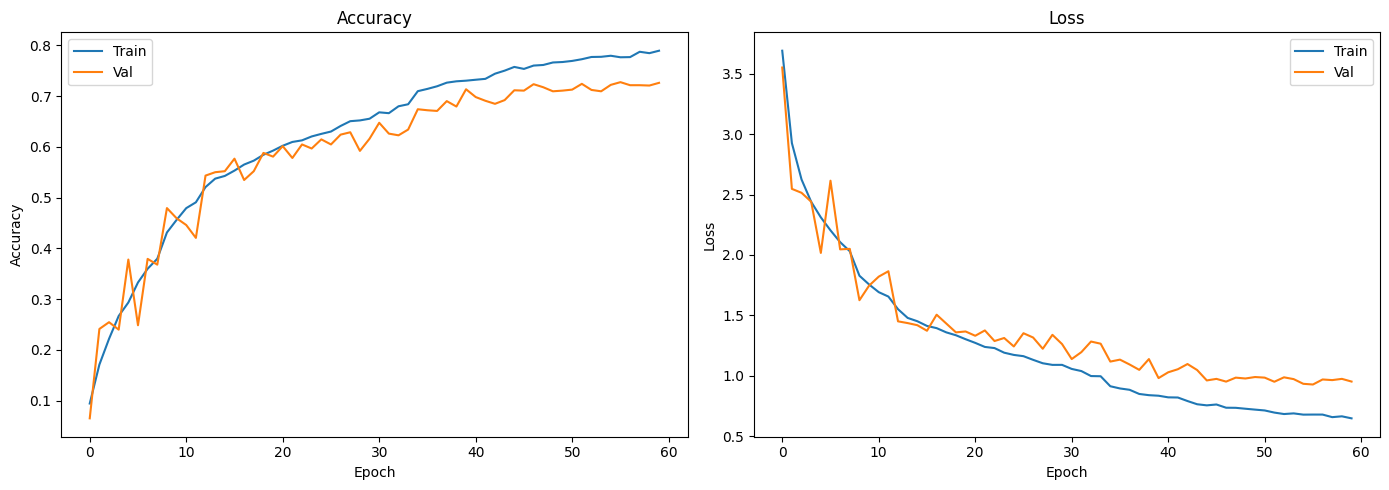

In [4]:

# ============================================================
# 📉 Plot Accuracy & Loss
# ============================================================
def plot_history(hist):
    plt.figure(figsize=(14, 5))

    # Accuracy
    plt.subplot(1, 2, 1)
    plt.plot(hist.history['accuracy'], label='Train')
    plt.plot(hist.history['val_accuracy'], label='Val')
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    # Loss
    plt.subplot(1, 2, 2)
    plt.plot(hist.history['loss'], label='Train')
    plt.plot(hist.history['val_loss'], label='Val')
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    plt.tight_layout()
    plt.show()

plot_history(history)
